In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (768, 9)

Column names:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(col, ":", (df[col] == 0).sum())


Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [ ]:
df_clean = df.copy()

for col in zero_columns:
    df_clean[col] = df_clean[col].replace(0, np.nan)

for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after preprocessing:")
print(df_clean.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X = df_clean[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "DiabetesPedigreeFunction",
        "Age"
    ]
]

y = df_clean["BMI"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 7)
Target shape: (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [ ]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[31.13832868 34.24670702 31.67491763 33.3239481  32.79992311 31.14397106
 24.16489507 32.03603466 32.76331153 30.51021187]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Model Performance")
print("--------------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Regression Model Performance
--------------------------------
Mean Absolute Error (MAE): 4.38672663677905
Mean Squared Error (MSE): 34.78837347216727
Root Mean Squared Error (RMSE): 5.898166958654805
R² Score: 0.20460981611878049


In [ ]:
comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred
})

comparison.head(10)

,Actual BMI,Predicted BMI
0,34.0,31.138329
1,35.7,34.246707
2,30.8,31.674918
3,24.6,33.323948
4,29.9,32.799923
5,37.7,31.143971
6,20.4,24.164895
7,33.8,32.036035
8,31.3,32.763312
9,33.7,30.510212


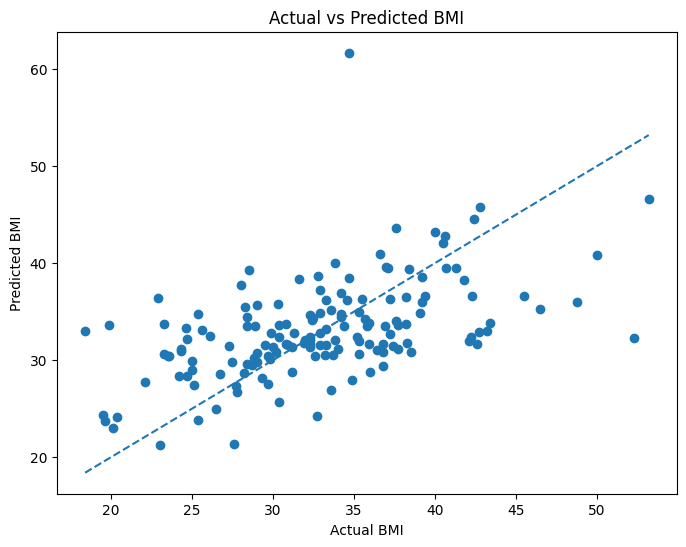

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [ ]:
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
668    2.861671
324    1.453293
624   -0.874918
690   -8.723948
473   -2.899923
204    6.556029
97    -3.764895
336    1.763965
568   -1.463312
148    3.189788
Name: BMI, dtype: float64


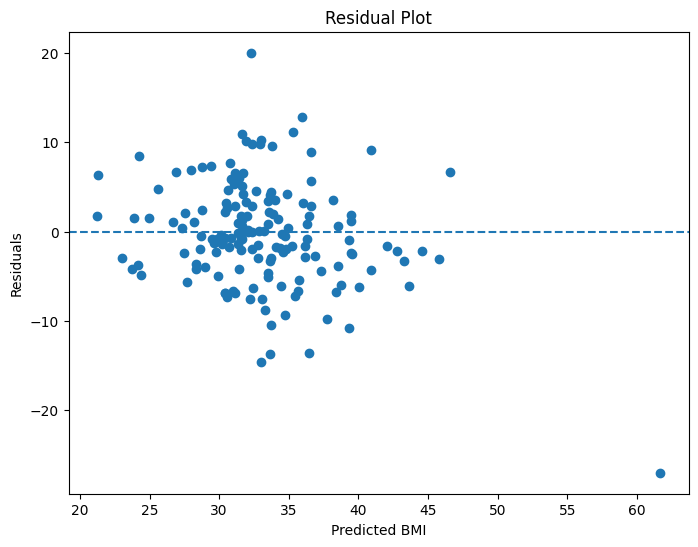

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted BMI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients


,Feature,Coefficient
0,Pregnancies,-0.006719
1,Glucose,0.029549
2,BloodPressure,0.108800
3,SkinThickness,0.424355
4,Insulin,0.003962
5,DiabetesPedigreeFunction,1.626967
6,Age,-0.089041
